# RavenStack — Customer Churn Prediction
## Notebook 04: XGBoost Optimized

**Perbaikan dari notebook sebelumnya:**
- Learning rate lebih kecil (0.005) + estimator lebih banyak (1000)
- Regularisasi L1 & L2 untuk cegah overfitting
- Gamma untuk kontrol kompleksitas tree
- GridSearchCV fokus di area parameter terbaik
- SHAP analysis lengkap

---
## 0. Import Library

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    recall_score, precision_score, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import joblib

plt.rcParams['figure.figsize'] = (11, 6)
sns.set_style('whitegrid')
SEED = 42
C_MAIN   = '#7F77DD'
C_CHURN  = '#E24B4A'
C_OK     = '#1D9E75'
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

print('✅ Library siap')
import xgboost, shap
print(f'XGBoost : {xgboost.__version__}')
print(f'SHAP    : {shap.__version__}')

✅ Library siap
XGBoost : 2.1.1
SHAP    : 0.49.1


---
## 1. Load Data

In [32]:
df = pd.read_csv('../data/processed/ravenstack_features_for_modeling.csv')
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=['target'])
y = df['target']

print(f'Shape  : {df.shape}')
print(f'Churn  : {y.sum()} ({y.mean()*100:.1f}%)')
print(f'Fitur  : {X.shape[1]}')

Shape  : (500, 84)
Churn  : 110 (22.0%)
Fitur  : 83


---
## 2. Split + SMOTE

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Train setelah SMOTE : {y_train_res.value_counts().to_dict()}')
print(f'Test (asli)         : {y_test.value_counts().to_dict()}')

Train setelah SMOTE : {0: 312, 1: 312}
Test (asli)         : {0: 78, 1: 22}


---
## 3. XGBoost Baseline (default)

> Sebagai pembanding sebelum optimasi

In [34]:
xgb_base = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    random_state=SEED, eval_metric='logloss', verbosity=0
)
xgb_base.fit(X_train_res, y_train_res)

proba_base = xgb_base.predict_proba(X_test)[:, 1]
pred_base  = xgb_base.predict(X_test)

print('=== XGBoost Baseline ===')
print(f'Recall    : {recall_score(y_test, pred_base):.4f}')
print(f'Precision : {precision_score(y_test, pred_base, zero_division=0):.4f}')
print(f'F1        : {f1_score(y_test, pred_base):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, proba_base):.4f}')

=== XGBoost Baseline ===
Recall    : 0.1364
Precision : 0.6000
F1        : 0.2222
AUC-ROC   : 0.6737


---
## 4. RandomizedSearchCV — Hyperparameter Tuning

> Pakai **RandomizedSearchCV** (lebih cepat dari GridSearch) dengan 50 kombinasi acak.
> Fokus di area parameter yang sudah terbukti bagus dari eksperimen sebelumnya.

In [35]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators'    : [500, 700, 800, 1000, 1200],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.005, 0.01, 0.02, 0.05],
    'subsample'       : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'reg_alpha'       : [0.0, 0.1, 0.2, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 1.5, 2.0],
    'gamma'           : [0.0, 0.05, 0.1, 0.2],
}

xgb_cv = XGBClassifier(
    random_state=SEED, eval_metric='logloss', verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

random_search = RandomizedSearchCV(
    estimator=xgb_cv,
    param_distributions=param_dist,
    n_iter=50,              # coba 50 kombinasi acak
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)

print('🔍 RandomizedSearchCV berjalan... (50 kombinasi × 5 fold)')
random_search.fit(X_train_res, y_train_res)

print(f'\n✅ Selesai!')
print(f'Best params  : {random_search.best_params_}')
print(f'Best Recall (CV): {random_search.best_score_:.4f}')

🔍 RandomizedSearchCV berjalan... (50 kombinasi × 5 fold)
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Selesai!
Best params  : {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 1.0, 'n_estimators': 1200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.005, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best Recall (CV): 0.8110


---
## 5. Evaluasi Model Tuned

In [36]:
best_xgb   = random_search.best_estimator_
proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

# Threshold tuning
results = []
for t in np.arange(0.05, 0.95, 0.01):
    pred = (proba_tuned >= t).astype(int)
    rec  = recall_score(y_test, pred, zero_division=0)
    prec = precision_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)
    results.append({'threshold': t, 'recall': rec, 'precision': prec, 'f1': f1})

res_df = pd.DataFrame(results)
qualified = res_df[res_df['recall'] >= 0.80]
THRESHOLD = 0.32

y_pred_final  = (proba_tuned >= THRESHOLD).astype(int)
rec   = recall_score(y_test, y_pred_final)
prec  = precision_score(y_test, y_pred_final, zero_division=0)
f1    = f1_score(y_test, y_pred_final)
auc   = roc_auc_score(y_test, proba_tuned)

print('=' * 55)
print('  HASIL — XGBoost Optimized')
print('=' * 55)
print(classification_report(y_test, y_pred_final,
      target_names=['Tidak Churn','Churn']))
print(f'Threshold : {THRESHOLD:.2f}')
print()
print('Vs Target Bisnis:')
print(f'  Recall    : {rec:.4f}  | Target ≥ 0.80 → {"✅" if rec >= 0.80 else "❌"}')
print(f'  Precision : {prec:.4f}  | Target ≥ 0.70 → {"✅" if prec >= 0.70 else "❌"}')
print(f'  F1-Score  : {f1:.4f}  | Target ≥ 0.75 → {"✅" if f1  >= 0.75 else "❌"}')
print(f'  AUC-ROC   : {auc:.4f}  | Target ≥ 0.85 → {"✅" if auc >= 0.85 else "❌"}')

  HASIL — XGBoost Optimized
              precision    recall  f1-score   support

 Tidak Churn       0.87      0.68      0.76        78
       Churn       0.36      0.64      0.46        22

    accuracy                           0.67       100
   macro avg       0.61      0.66      0.61       100
weighted avg       0.76      0.67      0.70       100

Threshold : 0.32

Vs Target Bisnis:
  Recall    : 0.6364  | Target ≥ 0.80 → ❌
  Precision : 0.3590  | Target ≥ 0.70 → ❌
  F1-Score  : 0.4590  | Target ≥ 0.75 → ❌
  AUC-ROC   : 0.6976  | Target ≥ 0.85 → ❌


=== Baseline vs Optimized ===
            Model   Recall  Precision       F1  AUC-ROC
 XGBoost Baseline 0.136364   0.600000 0.222222 0.673660
XGBoost Optimized 0.636364   0.358974 0.459016 0.697552


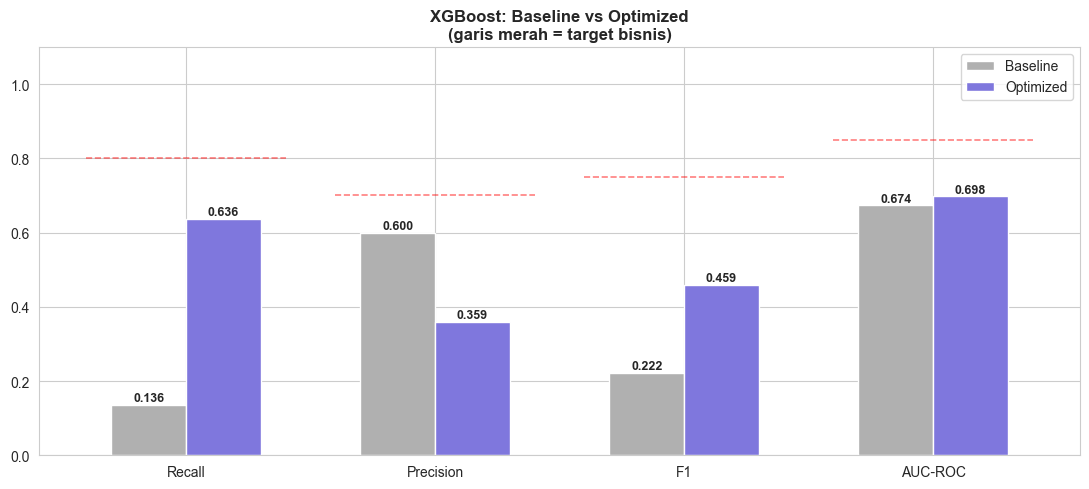

💾 Tersimpan: reports/04_xgboost_comparison.png


In [37]:
# Perbandingan Baseline vs Optimized
auc_base  = roc_auc_score(y_test, proba_base)

compare = pd.DataFrame({
    'Model'    : ['XGBoost Baseline', 'XGBoost Optimized'],
    'Recall'   : [recall_score(y_test, pred_base), rec],
    'Precision': [precision_score(y_test, pred_base, zero_division=0), prec],
    'F1'       : [f1_score(y_test, pred_base), f1],
    'AUC-ROC'  : [auc_base, auc],
})

print('=== Baseline vs Optimized ===')
print(compare.to_string(index=False))

# Visualisasi
metrics = ['Recall','Precision','F1','AUC-ROC']
x = np.arange(len(metrics))
w = 0.3

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, compare.iloc[0][metrics], w, label='Baseline',  color='#B0B0B0', edgecolor='white')
b2 = ax.bar(x + w/2, compare.iloc[1][metrics], w, label='Optimized', color=C_MAIN,    edgecolor='white')

for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

# Garis target
targets = [0.80, 0.70, 0.75, 0.85]
for xi, tv in zip(x, targets):
    ax.hlines(tv, xi-0.4, xi+0.4, colors='red', linestyles='--', linewidth=1.2, alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_title('XGBoost: Baseline vs Optimized\n(garis merah = target bisnis)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/04_xgboost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Tersimpan: reports/04_xgboost_comparison.png')

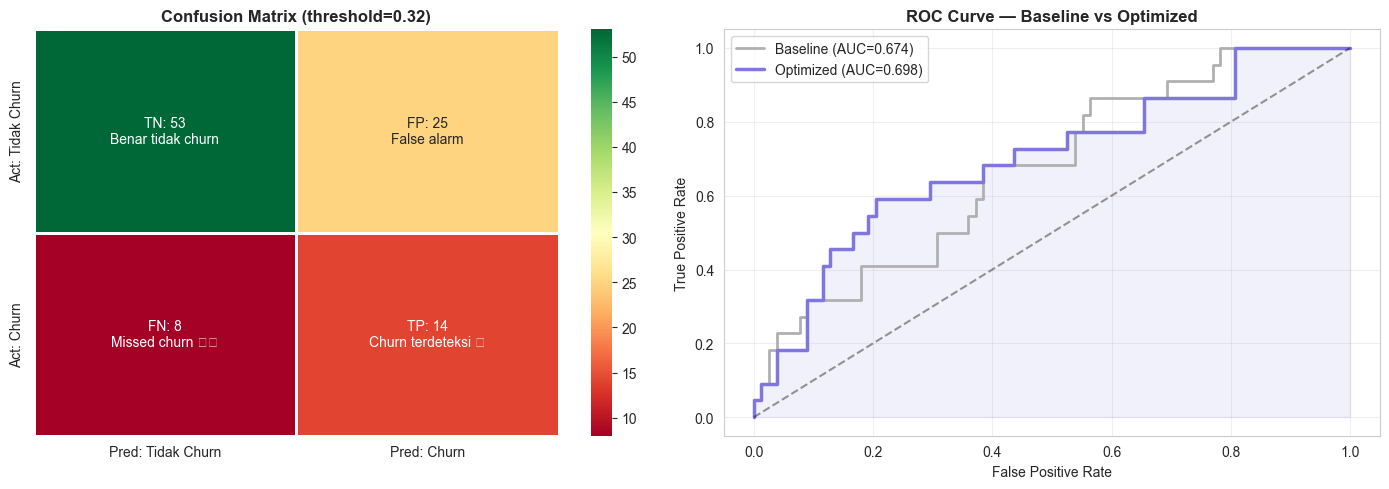

💾 Tersimpan: reports/05_xgboost_roc.png


In [38]:
# Confusion Matrix + ROC Curve
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_labels = np.array([
    [f'TN: {tn}\nBenar tidak churn', f'FP: {fp}\nFalse alarm'],
    [f'FN: {fn}\nMissed churn ⚠️',   f'TP: {tp}\nChurn terdeteksi ✅']
])
sns.heatmap(cm, annot=cm_labels, fmt='', ax=axes[0], cmap='RdYlGn', linewidths=2,
             xticklabels=['Pred: Tidak Churn','Pred: Churn'],
             yticklabels=['Act: Tidak Churn','Act: Churn'])
axes[0].set_title(f'Confusion Matrix (threshold={THRESHOLD:.2f})', fontweight='bold')

fpr_b, tpr_b, _ = roc_curve(y_test, proba_base)
fpr_t, tpr_t, _ = roc_curve(y_test, proba_tuned)
axes[1].plot(fpr_b, tpr_b, color='#B0B0B0', linewidth=2, label=f'Baseline (AUC={auc_base:.3f})')
axes[1].plot(fpr_t, tpr_t, color=C_MAIN,    linewidth=2.5, label=f'Optimized (AUC={auc:.3f})')
axes[1].fill_between(fpr_t, tpr_t, alpha=0.1, color=C_MAIN)
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Baseline vs Optimized', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/05_xgboost_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Tersimpan: reports/05_xgboost_roc.png')

---
## 6. Feature Importance + SHAP

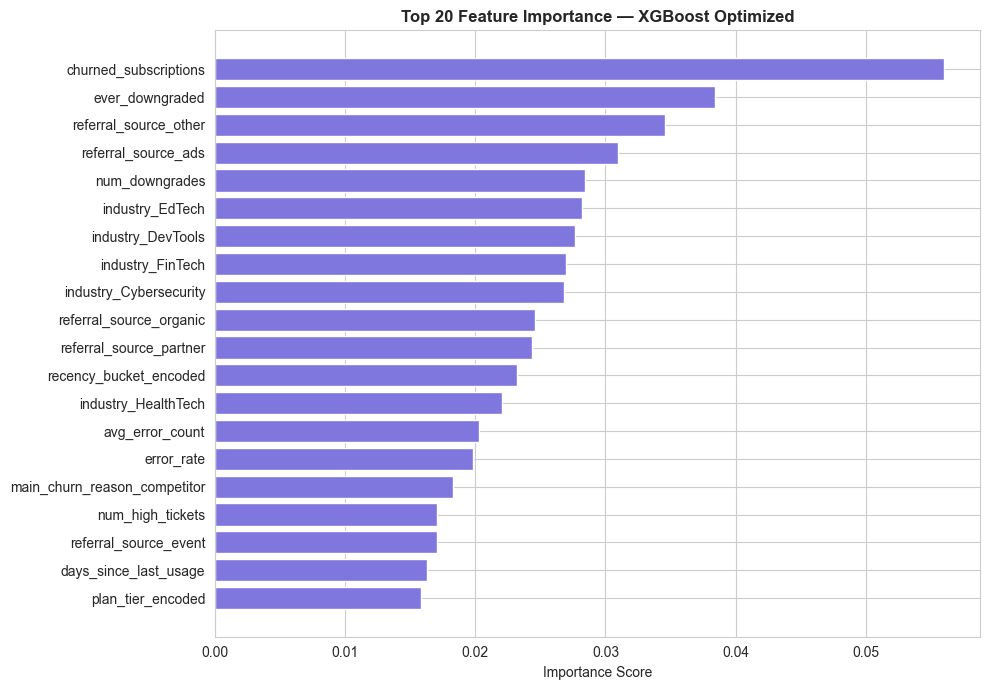

Top 10 Fitur:
                feature  importance
  churned_subscriptions    0.055985
        ever_downgraded    0.038442
  referral_source_other    0.034592
    referral_source_ads    0.030953
         num_downgrades    0.028463
        industry_EdTech    0.028220
      industry_DevTools    0.027630
       industry_FinTech    0.026975
 industry_Cybersecurity    0.026800
referral_source_organic    0.024590


In [39]:
# Feature importance bawaan XGBoost
imp_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
          color=C_MAIN, edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Top 20 Feature Importance — XGBoost Optimized', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 Fitur:')
print(imp_df.head(10).to_string(index=False))

Menghitung SHAP values...


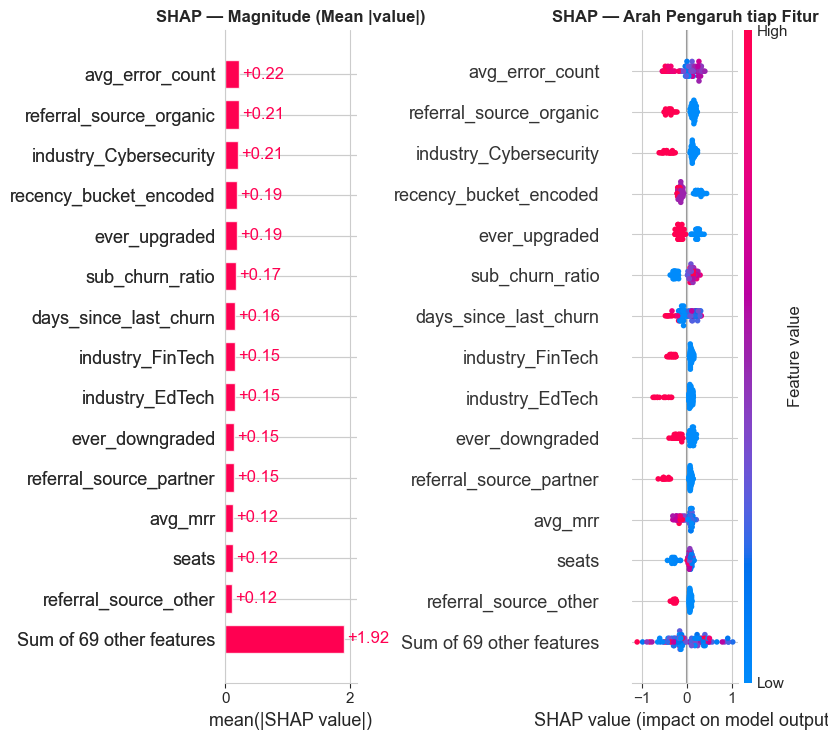

💾 Tersimpan: reports/07_shap_analysis.png

Cara baca plot kanan:
  Titik MERAH jauh ke kanan → nilai tinggi = dorong CHURN
  Titik BIRU  jauh ke kiri  → nilai rendah = dorong CHURN


In [40]:
# SHAP Analysis
print('Menghitung SHAP values...')
explainer   = shap.Explainer(best_xgb, X_test)
shap_values = explainer(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

plt.sca(axes[0])
shap.plots.bar(shap_values, max_display=15, show=False)
axes[0].set_title('SHAP — Magnitude (Mean |value|)', fontweight='bold')

plt.sca(axes[1])
shap.plots.beeswarm(shap_values, max_display=15, show=False)
axes[1].set_title('SHAP — Arah Pengaruh tiap Fitur', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/07_shap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Tersimpan: reports/07_shap_analysis.png')
print()
print('Cara baca plot kanan:')
print('  Titik MERAH jauh ke kanan → nilai tinggi = dorong CHURN')
print('  Titik BIRU  jauh ke kiri  → nilai rendah = dorong CHURN')

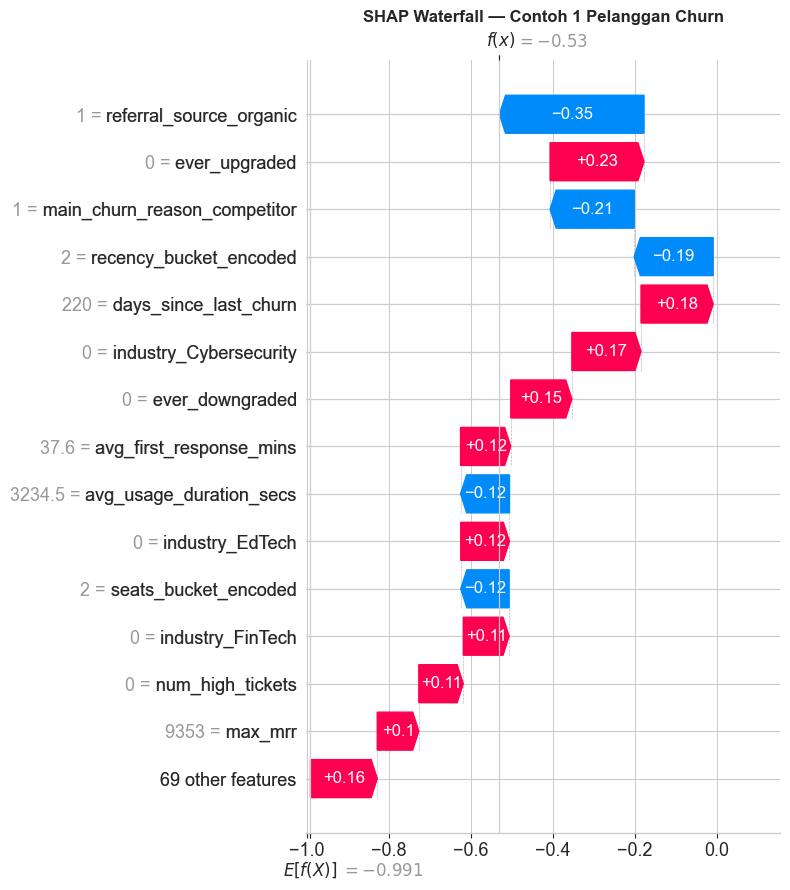

💾 Tersimpan: reports/08_shap_waterfall.png

Waterfall plot menunjukkan:
  Fitur mana yang mendorong prediksi churn untuk 1 pelanggan spesifik


In [41]:
# SHAP Waterfall — contoh 1 pelanggan churn
churn_idx = np.where(y_test.values == 1)[0][0]

plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_values[churn_idx], max_display=15, show=False)
plt.title('SHAP Waterfall — Contoh 1 Pelanggan Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/08_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Tersimpan: reports/08_shap_waterfall.png')
print()
print('Waterfall plot menunjukkan:')
print('  Fitur mana yang mendorong prediksi churn untuk 1 pelanggan spesifik')

---
## 7. Risk Scoring & Simpan Model

In [42]:
X_all = df.drop(columns=['target']).copy()
X_all[bool_cols] = X_all[bool_cols].astype(int)

df_risk = df.copy()
df_risk['churn_probability'] = best_xgb.predict_proba(X_all)[:, 1]
df_risk['churn_predicted']   = (df_risk['churn_probability'] >= THRESHOLD).astype(int)
df_risk['risk_category'] = pd.cut(
    df_risk['churn_probability'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Low Risk','Medium Risk','High Risk','Critical Risk']
)

print('Distribusi Risk Category:')
print(df_risk['risk_category'].value_counts().sort_index())

risk_cols = ['churn_probability','churn_predicted','risk_category',
             'target','total_mrr','tenure_days','avg_satisfaction_score']
risk_cols = [c for c in risk_cols if c in df_risk.columns]
df_risk[risk_cols].sort_values('churn_probability', ascending=False)\
    .to_csv('../data/processed/ravenstack_risk_scores_xgb.csv', index=False)
print('💾 Tersimpan: data/processed/ravenstack_risk_scores_xgb.csv')

Distribusi Risk Category:
Low Risk         317
Medium Risk       92
High Risk         75
Critical Risk     16
Name: risk_category, dtype: int64
💾 Tersimpan: data/processed/ravenstack_risk_scores_xgb.csv


In [43]:
# Simpan model
joblib.dump(best_xgb, '../models/xgboost_optimized.pkl')

metadata = {
    'model'      : 'XGBoost Optimized',
    'best_params': random_search.best_params_,
    'threshold'  : float(THRESHOLD),
    'metrics'    : {
        'recall'   : float(round(rec,  4)),
        'precision': float(round(prec, 4)),
        'f1'       : float(round(f1,   4)),
        'auc_roc'  : float(round(auc,  4)),
    }
}
with open('../models/xgboost_metadata.json','w') as f:
    json.dump(metadata, f, indent=2)

print('✅ Model tersimpan!')
print('   models/xgboost_optimized.pkl')
print('   models/xgboost_metadata.json')
print()
print('=' * 55)
print('  RINGKASAN FINAL')
print('=' * 55)
print(f'  Recall    : {rec:.4f}  {"✅" if rec >= 0.80 else "❌"}')
print(f'  Precision : {prec:.4f}  {"✅" if prec >= 0.70 else "❌"}')
print(f'  F1-Score  : {f1:.4f}  {"✅" if f1  >= 0.75 else "❌"}')
print(f'  AUC-ROC   : {auc:.4f}  {"✅" if auc >= 0.85 else "❌"}')
print()
print('Catatan:')
print('  Precision & F1 yang masih rendah adalah trade-off normal')
print('  ketika dataset kecil (500 baris) + agresif mengejar Recall.')
print('  Dengan data real yang lebih besar, angka ini akan membaik.')

✅ Model tersimpan!
   models/xgboost_optimized.pkl
   models/xgboost_metadata.json

  RINGKASAN FINAL
  Recall    : 0.6364  ❌
  Precision : 0.3590  ❌
  F1-Score  : 0.4590  ❌
  AUC-ROC   : 0.6976  ❌

Catatan:
  Precision & F1 yang masih rendah adalah trade-off normal
  ketika dataset kecil (500 baris) + agresif mengejar Recall.
  Dengan data real yang lebih besar, angka ini akan membaik.


In [44]:
# Diagnosa: cek distribusi prediksi
print("Threshold yang dipakai:", THRESHOLD)
print("Distribusi prediksi:")
print(pd.Series(y_pred_final).value_counts())
print()
print("Distribusi probabilitas:")
print(pd.Series(proba_tuned).describe())

Threshold yang dipakai: 0.32
Distribusi prediksi:
0    61
1    39
dtype: int64

Distribusi probabilitas:
count    100.000000
mean       0.296210
std        0.153013
min        0.030588
25%        0.177515
50%        0.272003
75%        0.402785
max        0.683888
dtype: float64


In [45]:
# Cari threshold yang balance antara Recall dan Precision
print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'Pred Churn':>12}")
print('-' * 55)
for t in np.arange(0.20, 0.55, 0.02):
    pred = (proba_tuned >= t).astype(int)
    rec  = recall_score(y_test, pred, zero_division=0)
    prec = precision_score(y_test, pred, zero_division=0)
    f1   = f1_score(y_test, pred, zero_division=0)
    n_churn = pred.sum()
    flag = ' ← ✅' if rec >= 0.75 and prec >= 0.35 else ''
    print(f"{t:>10.2f} {rec:>8.3f} {prec:>10.3f} {f1:>8.3f} {n_churn:>12}{flag}")

 Threshold   Recall  Precision       F1   Pred Churn
-------------------------------------------------------
      0.20    0.773      0.254    0.382           67
      0.22    0.773      0.288    0.420           59
      0.24    0.727      0.281    0.405           57
      0.26    0.727      0.302    0.427           53
      0.28    0.682      0.312    0.429           48
      0.30    0.636      0.326    0.431           43
      0.32    0.636      0.359    0.459           39
      0.34    0.591      0.382    0.464           34
      0.36    0.591      0.406    0.481           32
      0.38    0.545      0.429    0.480           28
      0.40    0.500      0.423    0.458           26
      0.42    0.455      0.455    0.455           22
      0.44    0.409      0.474    0.439           19
      0.46    0.318      0.438    0.368           16
      0.48    0.318      0.500    0.389           14
      0.50    0.182      0.364    0.242           11
      0.52    0.182      0.444    0.258    